In [4]:
from google.colab import files

uploaded = files.upload()


Saving WA_Fn-UseC_-HR-Employee-Attrition.csv to WA_Fn-UseC_-HR-Employee-Attrition.csv


IMPORTING LIBRARIES



In [51]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("charts", exist_ok=True)
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score


from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

TASK 1

In [6]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [7]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [8]:
print("Rows and Columns:", df.shape)

Rows and Columns: (1470, 35)


In [9]:
print(df.columns)


Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')


In [10]:
print("Target Column:", "Attrition")

Target Column: Attrition


In [11]:
attrition_counts = df["Attrition"].value_counts()

print(attrition_counts)

Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [12]:
attrition_rate = (df["Attrition"] == "Yes").mean() * 100

print(f"Attrition Rate: {attrition_rate:.2f}%")

Attrition Rate: 16.12%


In [13]:
numeric_columns = df.select_dtypes(include=np.number).columns
categorical_columns = df.select_dtypes(include="object").columns

print("Number of Numeric Columns:", len(numeric_columns))
print("Number of Categorical Columns:", len(categorical_columns))

print("\nNumeric Columns:")
print(numeric_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Number of Numeric Columns: 26
Number of Categorical Columns: 9

Numeric Columns:
Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

Categorical Columns:
Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')


Observations:
1. There are both numerical and categorical variables in the data.
2. The attrition percentage is extremely low compared to the retention percentage, suggesting that there is an imbalanced dataset as many more people remained with the organization than those who left.

TASK 2

In [14]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [15]:
df = df.drop(
    columns=[
        "EmployeeNumber",
        "Over18",
        "StandardHours"
    ]
)

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EnvironmentSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,3,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,4,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,1,...,3,4,1,6,3,3,2,2,2,2


In [16]:
df["Attrition"] = df["Attrition"].map({
    "Yes": 1,
    "No": 0
})

In [17]:
df["Attrition"].head()

,Attrition
0,1
1,0
2,1
3,0
4,0


In [18]:
categorical_columns = df.select_dtypes(include="object").columns

print(categorical_columns)

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')


In [19]:
df = pd.get_dummies(
    df,
    drop_first=True
)

In [20]:
df.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,1,2,94,3,2,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,1,3,61,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,1,4,92,2,1,...,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,1,4,56,3,1,...,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,1,40,3,1,...,True,False,False,False,False,False,False,True,False,False


In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()


In [22]:
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns

numeric_columns

Index(['Age', 'Attrition', 'DailyRate', 'DistanceFromHome', 'Education',
       'EmployeeCount', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [23]:
numeric_columns = numeric_columns.drop("Attrition")

In [24]:
df[numeric_columns] = scaler.fit_transform(df[numeric_columns])

In [25]:
df.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,0.446350,1,0.742527,-1.010909,-0.891688,0.0,-0.660531,1.383138,0.379672,-0.057788,...,False,False,False,False,False,True,False,False,True,True
1,1.322365,0,-1.297775,-0.147150,-1.868426,0.0,0.254625,-0.240677,-1.026167,-0.057788,...,False,False,False,False,True,False,False,True,False,False
2,0.008343,1,1.414363,-0.887515,-0.891688,0.0,1.169781,1.284725,-1.026167,-0.961486,...,True,False,False,False,False,False,False,False,True,True
3,-0.429664,0,1.461466,-0.764121,1.061787,0.0,1.169781,-0.486709,0.379672,-0.961486,...,False,False,False,False,True,False,False,True,False,True
4,-1.086676,0,-0.524295,-0.887515,-1.868426,0.0,-1.575686,-1.274014,0.379672,-0.961486,...,True,False,False,False,False,False,False,True,False,False


In [26]:
eda_df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")


TASK 3

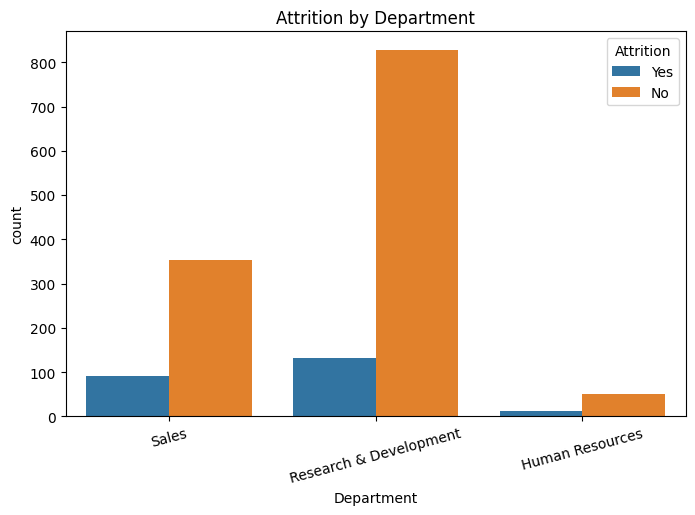

In [27]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=eda_df,
    x="Department",
    hue="Attrition"
)

plt.title("Attrition by Department")
plt.xticks(rotation=15)

plt.show()

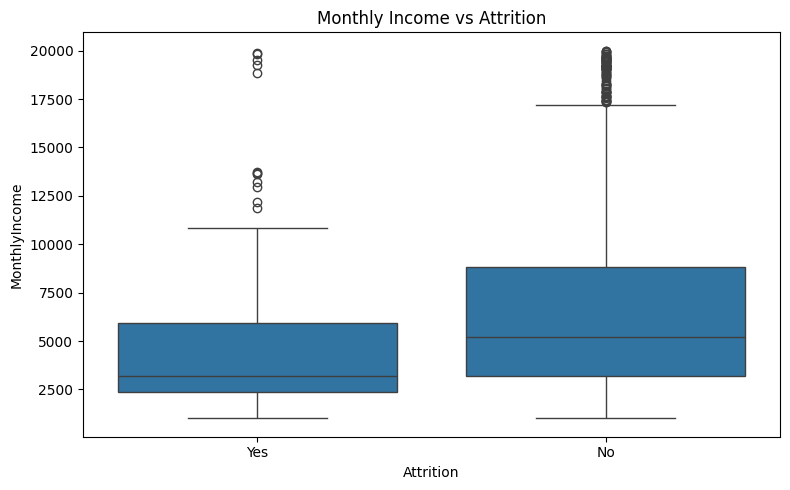

In [62]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=eda_df,
    x="Attrition",
    y="MonthlyIncome"
)

plt.title("Monthly Income vs Attrition")

plt.tight_layout()

plt.savefig("charts/monthly_income_attrition.png")

plt.show()

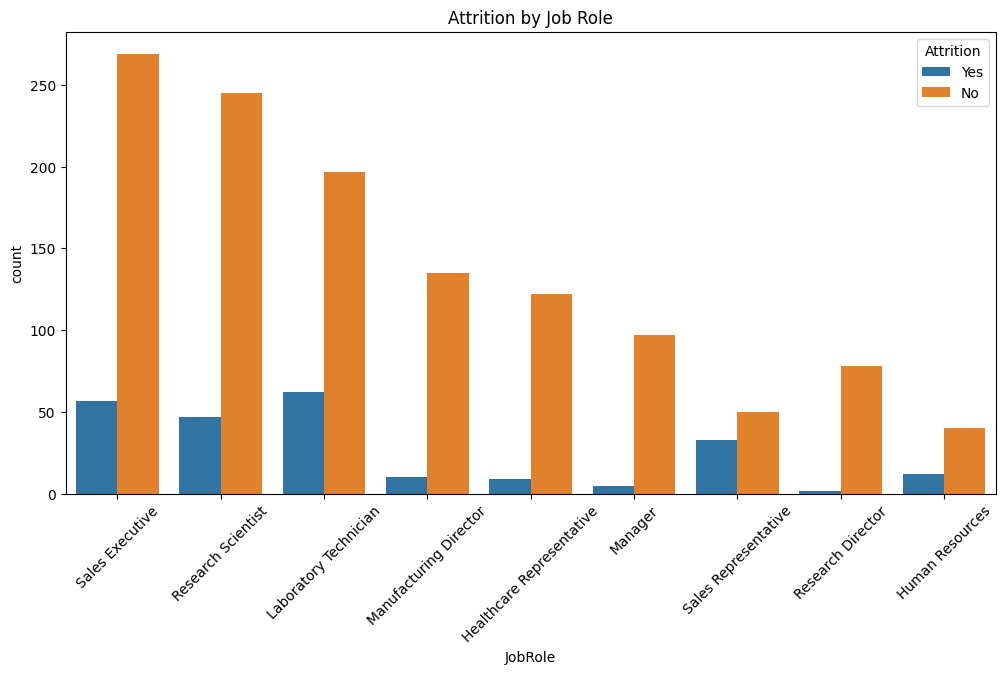

In [28]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=eda_df,
    x="JobRole",
    hue="Attrition"
)

plt.xticks(rotation=45)

plt.title("Attrition by Job Role")

plt.show()

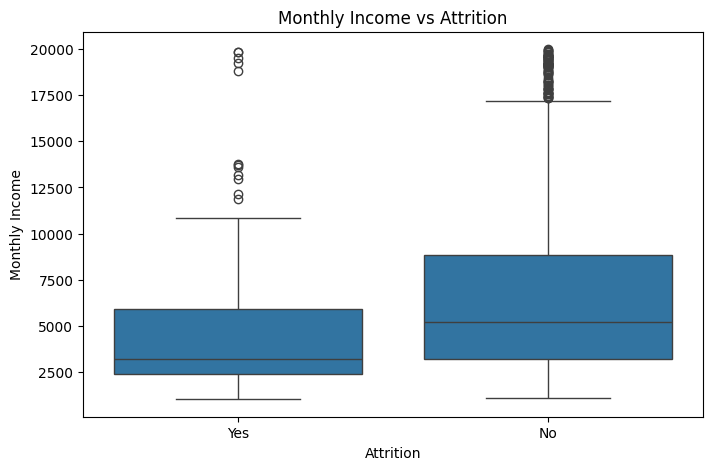

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=eda_df,
    x="Attrition",
    y="MonthlyIncome"
)

plt.title("Monthly Income vs Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")

plt.show()

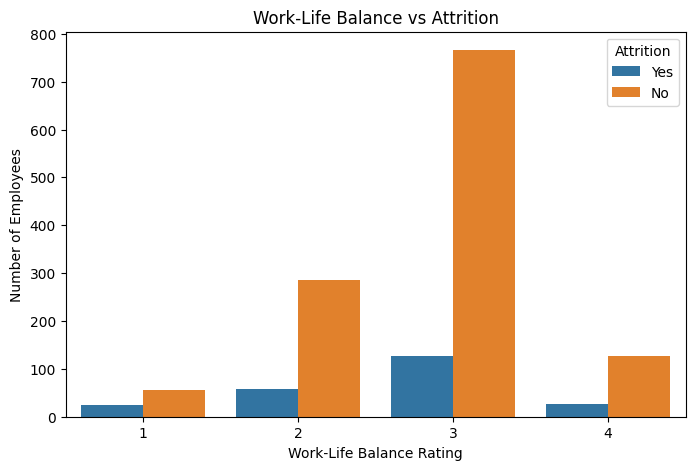

In [30]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=eda_df,
    x="WorkLifeBalance",
    hue="Attrition"
)

plt.title("Work-Life Balance vs Attrition")
plt.xlabel("Work-Life Balance Rating")
plt.ylabel("Number of Employees")

plt.show()

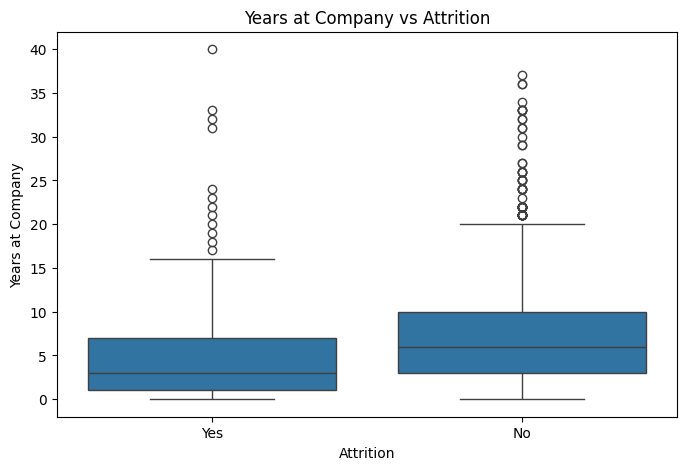

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=eda_df,
    x="Attrition",
    y="YearsAtCompany"
)

plt.title("Years at Company vs Attrition")
plt.xlabel("Attrition")
plt.ylabel("Years at Company")

plt.show()

TASK 4

In [32]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

print(X.shape)
print(y.shape)

(1470, 45)
(1470,)


In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (1176, 45)
Testing Data: (294, 45)


In [34]:
log_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train, y_train)

print("Logistic Regression Trained Successfully")

Logistic Regression Trained Successfully


In [35]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest Trained Successfully")

Random Forest Trained Successfully


In [36]:
gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_model.fit(X_train, y_train)

print("Gradient Boosting Trained Successfully")

Gradient Boosting Trained Successfully


In [37]:
log_pred = log_model.predict(X_test)

rf_pred = rf_model.predict(X_test)

gb_pred = gb_model.predict(X_test)

In [38]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred)
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.755102
1,Random Forest,0.840136
2,Gradient Boosting,0.853741


 MODEL EVALUATION

In [41]:
models = {
    "Logistic Regression": (log_model, log_pred),
    "Random Forest": (rf_model, rf_pred),
    "Gradient Boosting": (gb_model, gb_pred)
}

results = []

for name, (model, pred) in models.items():

    results.append({
        "Model": name,
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(
            y_test,
            model.predict_proba(X_test)[:,1]
        )
    })

results_df = pd.DataFrame(results)

results_df

,Model,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.356322,0.659574,0.462687,0.803601
1,Random Forest,0.500000,0.063830,0.113208,0.775218
2,Gradient Boosting,0.611111,0.234043,0.338462,0.793781


In [43]:
for name, (model, pred) in models.items():

    print("="*50)
    print(name)
    print("="*50)

    print(classification_report(y_test, pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.92      0.77      0.84       247
           1       0.36      0.66      0.46        47

    accuracy                           0.76       294
   macro avg       0.64      0.72      0.65       294
weighted avg       0.83      0.76      0.78       294

Random Forest
              precision    recall  f1-score   support

           0       0.85      0.99      0.91       247
           1       0.50      0.06      0.11        47

    accuracy                           0.84       294
   macro avg       0.67      0.53      0.51       294
weighted avg       0.79      0.84      0.78       294

Gradient Boosting
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.61      0.23      0.34        47

    accuracy                           0.85       294
   macro avg       0.74      0.60      0.63       294
weighted avg       0.8

In [44]:
best_model = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

best_model


,Model,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.356322,0.659574,0.462687,0.803601
2,Gradient Boosting,0.611111,0.234043,0.338462,0.793781
1,Random Forest,0.500000,0.063830,0.113208,0.775218


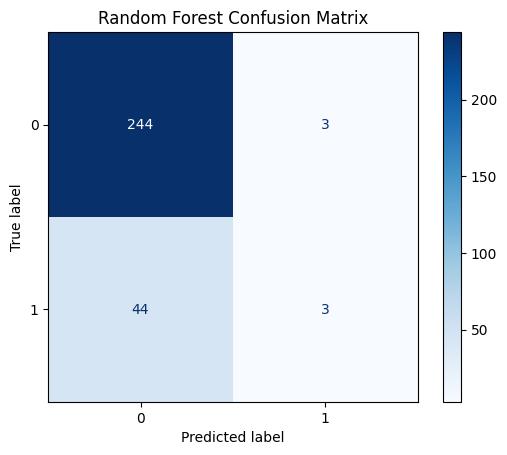

In [45]:
ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")

plt.show()

In [48]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
10,MonthlyIncome,0.071443
0,Age,0.061937
17,TotalWorkingYears,0.054522
1,DailyRate,0.051280
11,MonthlyRate,0.047951
23,YearsWithCurrManager,0.046725
20,YearsAtCompany,0.046042
44,OverTime_Yes,0.043751
6,HourlyRate,0.043070
2,DistanceFromHome,0.042327


In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

In [49]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
10,MonthlyIncome,0.071443
0,Age,0.061937
17,TotalWorkingYears,0.054522
1,DailyRate,0.051280
11,MonthlyRate,0.047951
23,YearsWithCurrManager,0.046725
20,YearsAtCompany,0.046042
44,OverTime_Yes,0.043751
6,HourlyRate,0.043070
2,DistanceFromHome,0.042327


VISULIZATION

In [52]:
plt.savefig("charts/attrition_department.png")

<Figure size 640x480 with 0 Axes>

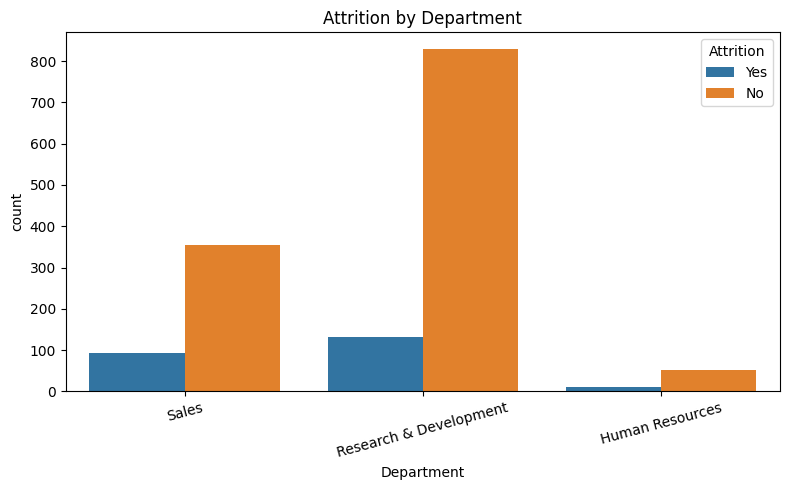

In [53]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=eda_df,
    x="Department",
    hue="Attrition"
)

plt.title("Attrition by Department")
plt.xticks(rotation=15)

plt.tight_layout()
plt.savefig("charts/attrition_department.png")

plt.show()

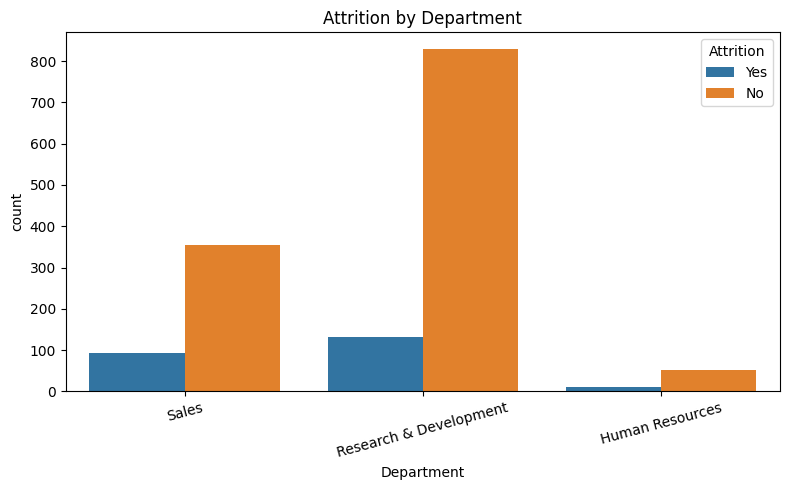

In [54]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=eda_df,
    x="Department",
    hue="Attrition"
)

plt.title("Attrition by Department")
plt.xticks(rotation=15)

plt.tight_layout()
plt.savefig("charts/attrition_department.png")

plt.show()

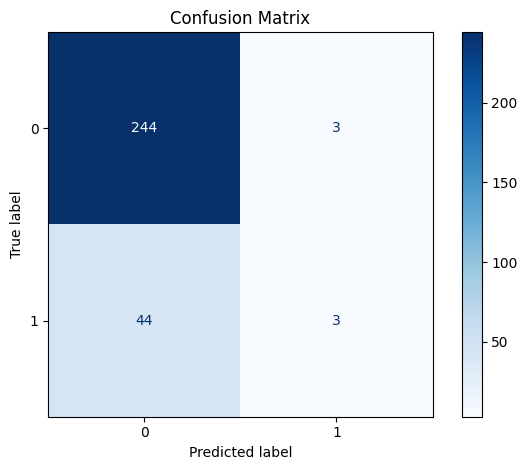

In [58]:
ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.tight_layout()
plt.savefig("charts/confusion_matrix.png")

plt.show()

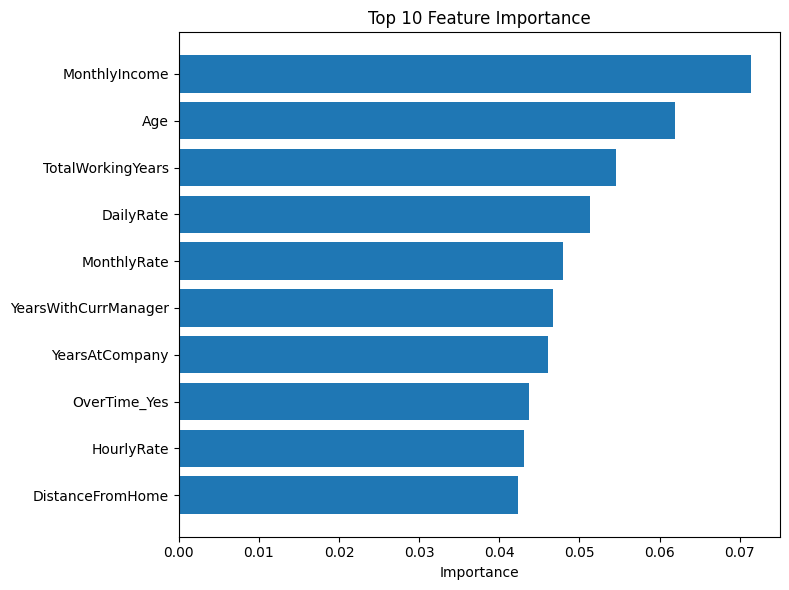

In [56]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

plt.figure(figsize=(8,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Top 10 Feature Importance")
plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig("charts/feature_importance.png")

plt.show()

<Figure size 800x600 with 0 Axes>

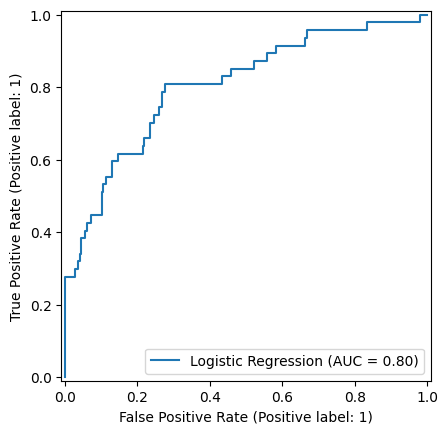

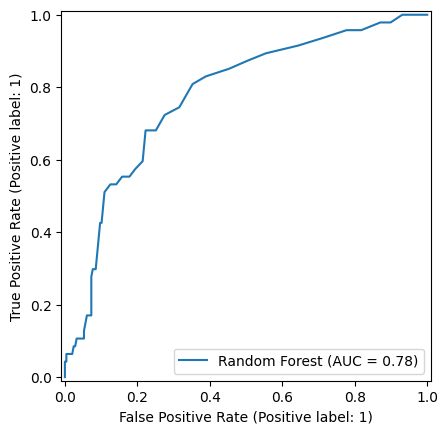

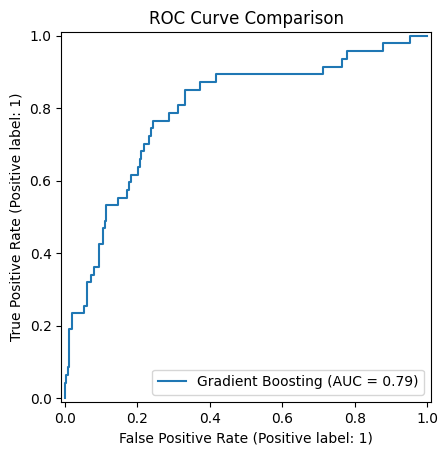

In [59]:
plt.figure(figsize=(8,6))

RocCurveDisplay.from_estimator(
    log_model,
    X_test,
    y_test,
    name="Logistic Regression"
)

RocCurveDisplay.from_estimator(
    rf_model,
    X_test,
    y_test,
    name="Random Forest"
)

RocCurveDisplay.from_estimator(
    gb_model,
    X_test,
    y_test,
    name="Gradient Boosting"
)

plt.title("ROC Curve Comparison")

plt.show()

In [64]:
from google.colab import files

for file in os.listdir("charts"):
    files.download(f"charts/{file}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

HR INSIGHTS & BUSINESS RECOMMENDATIONS

Based on the analysis, the most important factors influencing employee attrition were overtime, monthly income, years at the company, and job role. Employees in certain departments and job roles showed a higher tendency to leave, so HR should prioritize these groups for retention efforts. Salary alone does not explain why employees leave; work-life balance, job satisfaction, career growth, and overtime also play significant roles. To reduce attrition, the company should regularly identify employees at higher risk of leaving and provide career development opportunities, flexible work arrangements, and workload support where needed. HR should also conduct regular employee feedback sessions to address concerns before employees decide to resign. One limitation of this model is that it learns from historical company data, so future predictions may change if employee behavior or company policies change.
